In [3]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [4]:
DATA_DIR = "titan-hf-5"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Feedline Pressure",
           "pres_3": "PT3 Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure"}

DRIVERS = {0: {"name": "Ox Fill", "False": "Close", "True": "Open"},
           1: {"name": "Ground Vent", "False": "Close", "True": "Open"},
           2: {"name": "Pressurization", "False": "Open", "True": "Close"},
           3: {"name": "Engine Vent", "False": "Close", "True": "Open"},
           4: {"name": "Ignition", "False": "Shutoff", "True": "Ignite"}}

In [5]:
prep.process_events_quonkboard(DATA_DIR, DRIVERS)

 contents: 34775
34775


In [6]:
prep.process_data(DATA_DIR, SENSORS)
from time import time

In [7]:
events = prep.import_events(DATA_DIR)
labels, data = prep.import_data(DATA_DIR, events)
times = data[:, 0]

print(f"HF5 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

HF5 Data Summary 
----------------- 
 Sensors: 5 
 Samples: 1773301 
 Events:  21


In [8]:
cc_pres = data[:,2]
axial_load = data[:,1]
new_col = 2.43*cc_pres - 16.5
print(labels)
labels = np.append(labels,"Normalized thrust")
print(labels)
print(axial_load.size)
data = np.column_stack((data,new_col))


['Time (s)' 'LC1 Axial Load' 'PT1 Combustion Chamber Pressure'
 'PT2 Feedline Pressure' 'PT3 Injector Pressure' 'PT4 Ox-Tank Pressure']
['Time (s)' 'LC1 Axial Load' 'PT1 Combustion Chamber Pressure'
 'PT2 Feedline Pressure' 'PT3 Injector Pressure' 'PT4 Ox-Tank Pressure'
 'Normalized thrust']
1773301


In [9]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=10, window="blackman")

5441.0
1632300
[-5.9003157 -4.6873326 -3.4743009 ... -3.8786286 -3.8786286 -2.2612692]


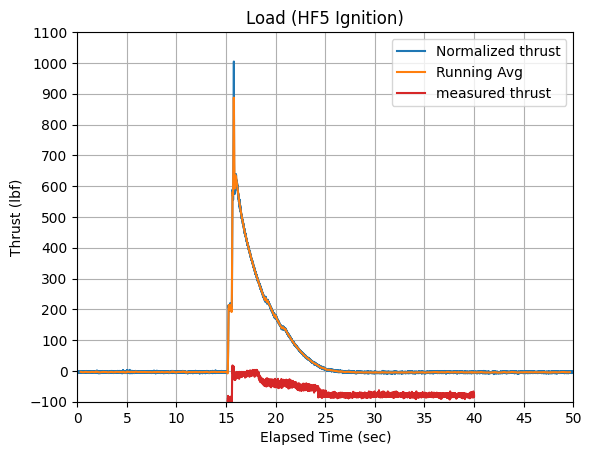

In [10]:
ep.plot(sensor_id=6, event_id=17, duration=50, filter=lpf,
        title="Load (HF5 Ignition)", ylabel="Thrust (lbf)",
        legend="Normalized thrust",num_xticks=11, dif_yticks=100)
ep.add_curve(sensor_id=1, event_id=17, duration=40, legend="measured thrust",
             color="tab:red")
plt.show()

5441.0
1632300
[728.07976 728.57899 728.91178 ...  -9.22057  -8.55499 -10.21895]


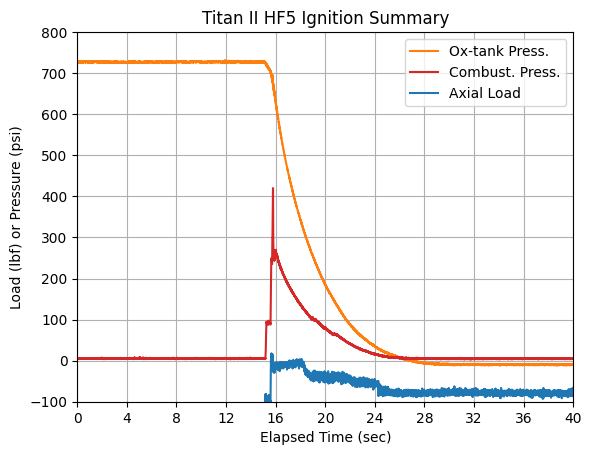

In [11]:
ep.plot(sensor_id=5, event_id=17, duration=40, filter=None,
        title="Titan II HF5 Ignition Summary", ylabel="Load (lbf) or Pressure (psi)",
        legend="Ox-tank Press.", num_xticks=11, dif_yticks=100, color="tab:orange")
ep.add_curve(sensor_id=2, event_id=17, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=1, event_id=17, duration=40, legend="Axial Load", 
             color="tab:blue")
plt.show()

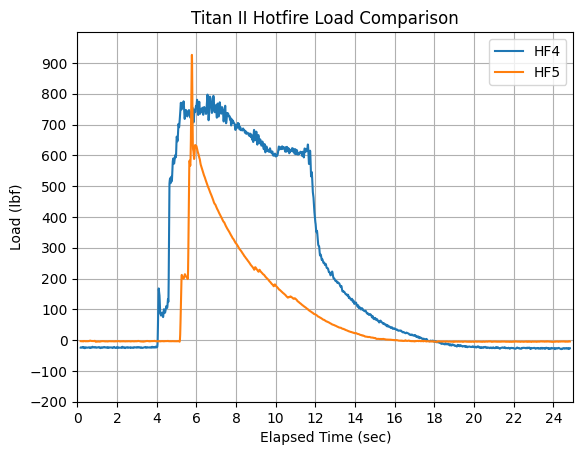

In [16]:
lpf = LPF(fs=300, length=51, cutoff=15, window="blackman")

DATA_DIR_HF4 = "titan-hf-4"
events_hf4 = [{'secs': '6519', 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': '6709', 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
label_hf4, data_hf4 = prep.import_data(DATA_DIR_HF4, events_hf4)
times_hf4 = data_hf4[:, 0]

time_start = float(events[17]["secs"])+10.0
time_end = time_start + 25
sample_start = vis.nearest_sample(data, time_start)
sample_end = vis.nearest_sample(data, time_end)
times_event = [t - time_start for t in times[sample_start:sample_end]]
data_event = data[sample_start:sample_end, 6]

time_start_hf4 = 6519.0
time_end_hf4 = time_start_hf4 + 25
sample_start_hf4 = vis.nearest_sample(data_hf4, time_start_hf4)
sample_end_hf4 = vis.nearest_sample(data_hf4, time_end_hf4)
times_event_hf4 = [t - time_start_hf4 for t in times_hf4[sample_start_hf4:sample_end_hf4]]
data_event_hf4 = data_hf4[sample_start_hf4:sample_end_hf4, 1]

plt.figure(dpi=100)
plt.plot(times_event_hf4[51:-51],
         lpf.apply(data_event_hf4)[51:-51],
         label="HF4", c="tab:blue")
plt.plot(times_event[51:-51],
         lpf.apply(data_event)[51:-51],
         label="HF5", c="tab:orange")
plt.legend(); plt.grid()
plt.title("Titan II Hotfire Load Comparison")
plt.xlabel("Elapsed Time (sec)"); plt.ylabel("Load (lbf)")
plt.xlim((0, 25)); plt.ylim((-200, 1000))
plt.xticks(range(0, 26, 2)); plt.yticks(range(-200, 1000, 100))
plt.show()